In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
cek_df=pd.read_csv("StudentsPerformance.csv")

In [14]:
print(cek_df.columns)
print(len(cek_df))
print(cek_df.info())

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='object')
1000
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB
None


In [8]:
score_math=cek_df['math score']
score_read=cek_df['reading score']
score_write=cek_df['writing score']
print(score_math.skew(),score_math.kurt())

-0.27893514909431694 0.27496405752108455


<Axes: xlabel='writing score', ylabel='Count'>

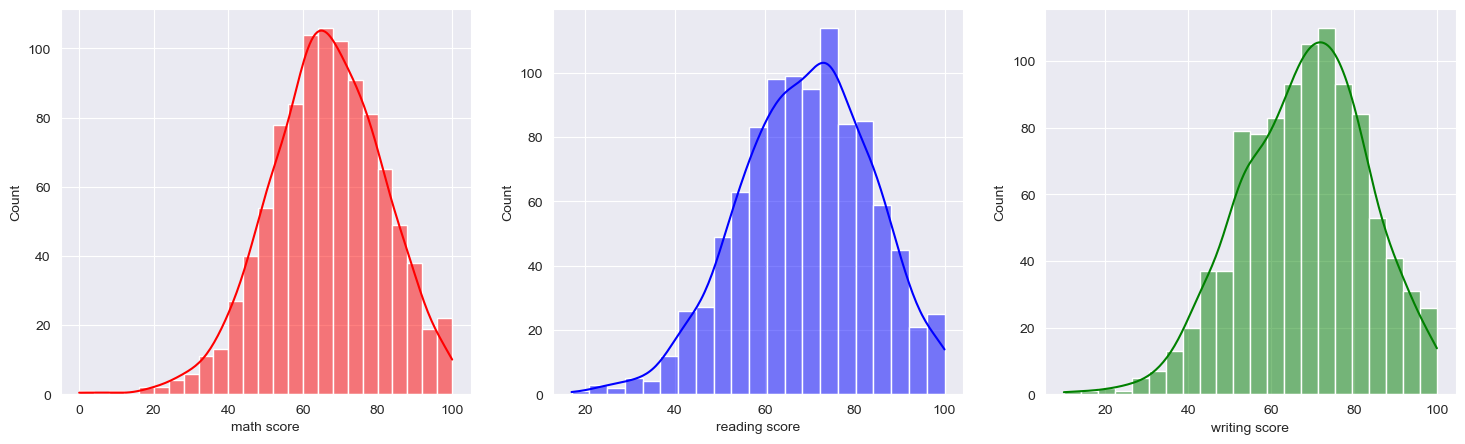

In [24]:
fig,axes=plt.subplots(nrows=1,ncols=3,figsize=(18,5))
sns.histplot(score_math,kde=True,color='red',ax=axes[0],label='math score')
sns.histplot(score_read,kde=True,color='blue',ax=axes[1],label='reading score')
sns.histplot(score_write,kde=True,color='green',ax=axes[2],label='writing score')

In [5]:
umur=pd.read_csv("SOCR-HeightWeight.csv")

In [23]:
umur.describe()

,Index,Height(Inches),Weight(Pounds)
count,25000.000000,25000.000000,25000.000000
mean,12500.500000,67.993114,127.079421
std,7217.022701,1.901679,11.660898
min,1.000000,60.278360,78.014760
25%,6250.750000,66.704397,119.308675
50%,12500.500000,67.995700,127.157750
75%,18750.250000,69.272958,134.892850
max,25000.000000,75.152800,170.924000


In [7]:
weight_df=umur['Weight(Pounds)']
weight_df.describe()

count    25000.000000
mean       127.079421
std         11.660898
min         78.014760
25%        119.308675
50%        127.157750
75%        134.892850
max        170.924000
Name: Weight(Pounds), dtype: float64

<Axes: xlabel='Weight(Pounds)', ylabel='Count'>

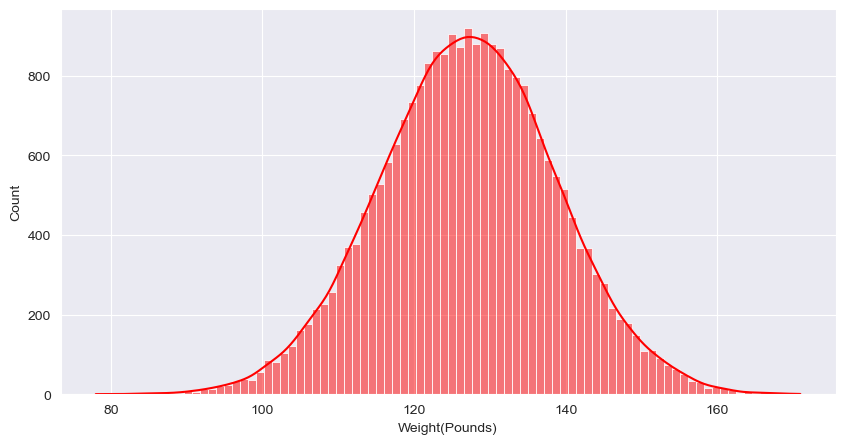

In [31]:
plt.figure(figsize=[10,5])
sns.histplot(weight_df,color='red',kde=True,label='Weight(Pounds)')

<Axes: xlabel='Weight(Pounds)', ylabel='Count'>

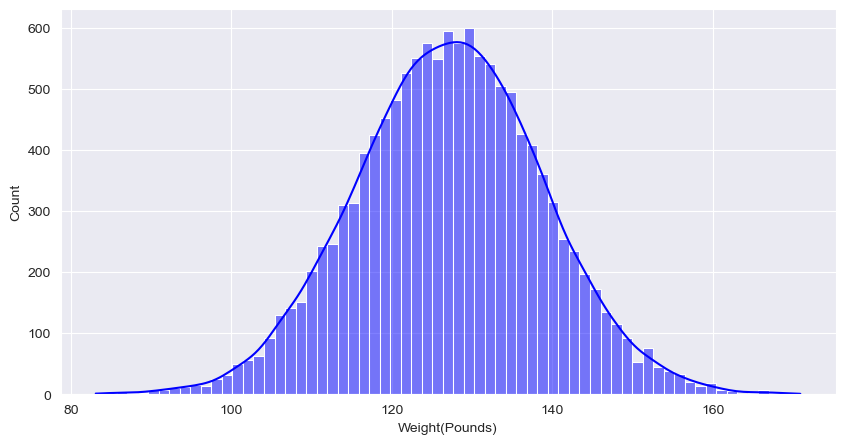

In [5]:
weight_df13=weight_df[:13000]
plt.figure(figsize=[10,5])
sns.histplot(weight_df13,color='blue',kde=True,label='Weight(Pounds)')

In [16]:
weight_df13.to_csv("weigt_data.csv")

In [6]:
weight_df13.info()

<class 'pandas.core.series.Series'>
RangeIndex: 13000 entries, 0 to 12999
Series name: Weight(Pounds)
Non-Null Count  Dtype  
--------------  -----  
13000 non-null  float64
dtypes: float64(1)
memory usage: 101.7 KB


In [7]:
weight_df13.describe()

count    13000.000000
mean       127.159473
std         11.645471
min         83.085270
25%        119.401375
50%        127.249500
75%        134.949225
max        170.924000
Name: Weight(Pounds), dtype: float64

In [10]:
weight_df13[weight_df13 >138].count()

np.int64(2246)

In [5]:
print(weight_df13.skew())
print(weight_df13.kurtosis())

-0.016672137862955676
0.08181044502416546


In [8]:
data_sampel=weight_df.sample(n=1000,random_state=42)

In [12]:
data_sampel.describe()

count    1000.000000
mean      126.907627
std        12.064943
min        82.382980
25%       119.105200
50%       127.065900
75%       134.773575
max       166.768700
Name: Weight(Pounds), dtype: float64

In [2]:
12.064943*12.064943

145.56284959324898

In [18]:
data_sampel.mean()+data_sampel.std()

np.float64(138.97257000679383)

<Axes: xlabel='Weight(Pounds)', ylabel='Count'>

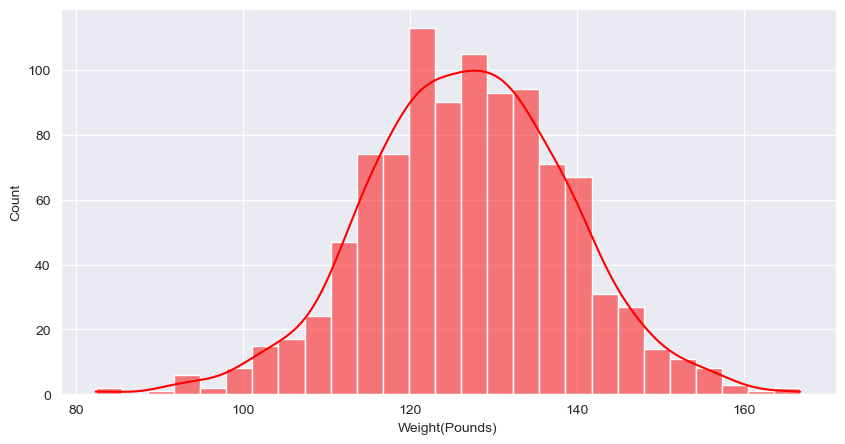

In [24]:
plt.figure(figsize=(10,5))
sns.histplot(data_sampel,color='red',kde=True,label='Weight(Pounds)')


In [27]:
print("skew",data_sampel.skew())
print("kurt",data_sampel.kurtosis())

skew -0.08320504790896958
kurt 0.34503423494890617


In [14]:
data_sampel.to_csv("weigt_data(random_13000).csv")

In [26]:
from scipy import stats

# Jalankan Uji Jarque-Bera pada data_sampel yang sudah ada
jb_stat, p_value = stats.jarque_bera(data_sampel)

print(f"=== HASIL UJI JARQUE-BERA ===")
print(f"JB Statistic : {jb_stat:.4f}")
print(f"P-Value      : {p_value:.4f}")

# Interpretasi Otomatis
if p_value > 0.05:
    print("\nKesimpulan: Data Berdistribusi NORMAL (Terima H0)")
else:
    print("\nKesimpulan: Secara statistik ketat TIDAK Normal (Tolak H0),")
    print("NAMUN, karena sampel sangat besar (13.000), p-value menjadi sangat sensitif.")
    print("Cukup perhatikan Skewness & Kurtosis yang mendekati 0 sebagai bukti Normalitas.")

=== HASIL UJI JARQUE-BERA ===
JB Statistic : 5.8913
P-Value      : 0.0526

Kesimpulan: Data Berdistribusi NORMAL (Terima H0)


In [14]:
import pandas as pd
import scipy.stats as stats

# 1. PERSIAPAN DATA
df = pd.read_csv('SOCR-HeightWeight.csv')
populasi = df['Weight(Pounds)']

print("Mencari jumlah sampel (N) > 1000 yang masih Lolos Uji Jarque-Bera...")
print("-" * 60)
print(f"{'N (Sampel)':<10} | {'P-Value':<10} | {'Status':<15}")
print("-" * 60)

# 2. LOOPING PENCARIAN (Dari 1000 s.d 5000, loncat tiap 50 angka)
# Kita pakai random_state=42 agar hasilnya konsisten
valid_n_tertinggi = 0

for n in range(1, 25000,50):
    # Ambil sampel
    sampel = populasi.sample(n=n, random_state=42)

    # Uji Jarque-Bera
    jb_stat, p_value = stats.jarque_bera(sampel)

    # Cek Status (Ambang batas 0.05)
    status = "✅ LOLOS" if p_value > 0.05 else "❌ GAGAL"

    # Print hasil
    print(f"{n:<10} | {p_value:.4f}     | {status}")

    # Simpan N tertinggi yang lolos
    if p_value > 0.05:
        valid_n_tertinggi = n

print("-" * 60)
print(f"REKOMENDASI: Gunakan N = {valid_n_tertinggi} untuk makalah Anda.")

Mencari jumlah sampel (N) > 1000 yang masih Lolos Uji Jarque-Bera...
------------------------------------------------------------
N (Sampel) | P-Value    | Status         
------------------------------------------------------------
1          | nan     | ❌ GAGAL
51         | 0.8643     | ✅ LOLOS
101        | 0.7054     | ✅ LOLOS
151        | 0.5401     | ✅ LOLOS
201        | 0.4780     | ✅ LOLOS
251        | 0.6125     | ✅ LOLOS
301        | 0.6180     | ✅ LOLOS
351        | 0.7379     | ✅ LOLOS
401        | 0.5817     | ✅ LOLOS
451        | 0.4965     | ✅ LOLOS
501        | 0.5321     | ✅ LOLOS
551        | 0.4423     | ✅ LOLOS
601        | 0.2516     | ✅ LOLOS
651        | 0.2009     | ✅ LOLOS
701        | 0.1481     | ✅ LOLOS
751        | 0.0372     | ❌ GAGAL
801        | 0.0254     | ❌ GAGAL
851        | 0.0136     | ❌ GAGAL
901        | 0.0248     | ❌ GAGAL
951        | 0.0353     | ❌ GAGAL
1001       | 0.0503     | ✅ LOLOS
1051       | 0.0357     | ❌ GAGAL
1101       | 0.0221   

In [3]:
import pandas as pd
import scipy.stats as stats

# 1. LOAD & SAMPLE (Sama seperti prosedur Bab 3)
df = pd.read_csv('SOCR-HeightWeight.csv')
data = df['Weight(Pounds)'].sample(n=1000, random_state=42)

# 2. HITUNG PARAMETER
mean_val = data.mean()
std_val = data.std()

# 3. TENTUKAN BATAS (Mean +/- 1 SD)
batas_bawah = mean_val - std_val  # Untuk Weight Gainer
batas_atas = mean_val + std_val   # Untuk Fat Burner

# 4. HITUNG SCIPY (BAGIAN PENTING)
# Peluang Weight Gainer (P < Batas Bawah)
# Rumus: stats.norm.cdf(x, loc=mean, scale=std)
prob_weight_gainer = stats.norm.cdf(batas_bawah, mean_val, std_val)

# Peluang Fat Burner (P > Batas Atas)
# Rumus: 1 - stats.norm.cdf(...)
prob_fat_burner = 1 - stats.norm.cdf(batas_atas, mean_val, std_val)

# 5. PRINT HASIL UNTUK DICOPY KE WORD
print("=== HASIL PERHITUNGAN UNTUK BAB IV ===")
print(f"Mean (Rata-rata) : {mean_val:.4f}")
print(f"Std Deviasi      : {std_val:.4f}")
print("-" * 40)
print("1. PRODUK WEIGHT GAINER (Underweight)")
print(f"   Batas Bawah (Mean - 1SD) : {batas_bawah:.4f} lbs")
print(f"   Nilai Probability (Desimal): {prob_weight_gainer:.4f}")
print(f"   Nilai Persentase           : {prob_weight_gainer * 100:.2f}%")
print("-" * 40)
print("2. PRODUK FAT BURNER (Overweight)")
print(f"   Batas Atas (Mean + 1SD)  : {batas_atas:.4f} lbs")
print(f"   Nilai Probability (Desimal): {prob_fat_burner:.4f}")
print(f"   Nilai Persentase           : {prob_fat_burner * 100:.2f}%")

=== HASIL PERHITUNGAN UNTUK BAB IV ===
Mean (Rata-rata) : 126.9076
Std Deviasi      : 12.0649
----------------------------------------
1. PRODUK WEIGHT GAINER (Underweight)
   Batas Bawah (Mean - 1SD) : 114.8427 lbs
   Nilai Probability (Desimal): 0.1587
   Nilai Persentase           : 15.87%
----------------------------------------
2. PRODUK FAT BURNER (Overweight)
   Batas Atas (Mean + 1SD)  : 138.9726 lbs
   Nilai Probability (Desimal): 0.1587
   Nilai Persentase           : 15.87%


In [20]:
from scipy import stats

print(stats.norm.cdf((data_sampel.mean()-data_sampel.std()),data_sampel.mean(),data_sampel.std()))
print(1-stats.norm.cdf((data_sampel.mean()+data_sampel.std()),data_sampel.mean(),data_sampel.std()))

0.15865525393145702
0.1586552539314574


In [21]:
data_sampel.std()**2

145.56285217017233